In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
import os

import poppy
import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import esc_fresnel
print(esc_fresnel.path)

import esc_fresnel.utils as utils
from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel.imshows import imshow1, imshow2, imshow3, imshow
import esc_fresnel.esc_fresnel_subap as esc
import esc_fresnel.esc_optics as esc_optics


/home/kianmilani/Projects/esc-fresnel/esc_fresnel


# Create an instance of the Fresnel model and check some of the parameters used in the propagation code. 

1


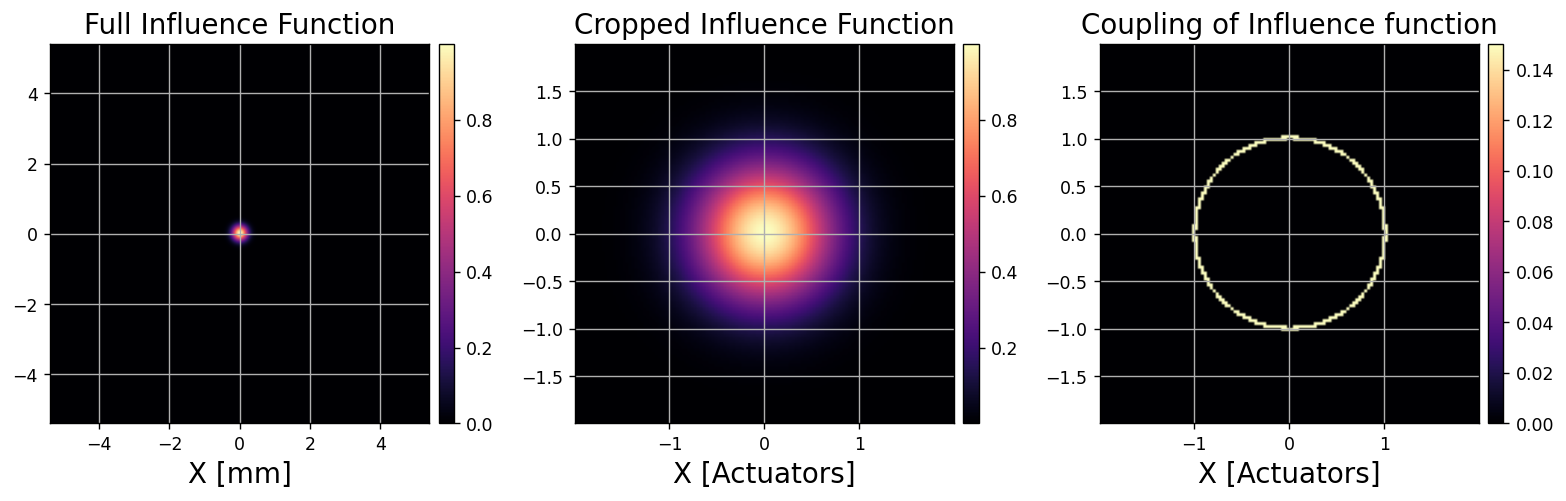

In [2]:
reload(esc)
M = esc.single()

inf_fun_coupling_region = (0.15-0.01<M.DM.inf_fun) & (M.DM.inf_fun<0.15+0.01)

imshow(
    [M.DM.inf_fun, M.DM.inf_fun, inf_fun_coupling_region],
    titles=['Full Influence Function', 'Cropped Influence Function', 'Coupling of Influence function'],
    xlabels=['X [mm]', 'X [Actuators]', 'X [Actuators]'],
    title_fzs=[16]*3,
    label_fzs=[16]*3,
    pxscls=[M.DM.pixelscale.to_value(u.mm/u.pix), 1/M.DM.inf_sampling, 1/M.DM.inf_sampling],
    cmaps=['magma']*3,
    grids=[1]*3,
    norms=[None, None, Normalize(vmax=0.15)],
    npix=[None, int(np.round(4*M.DM.inf_sampling)), int(np.round(4*M.DM.inf_sampling))],
    wspace=0.3,
)

In [5]:
optic_names = list(esc_optics.apparent_fls_theo.keys())

for i in range(len(optic_names)):
    name = optic_names[i]
    if 'oap' in name:
        print(name)
        print(f'Theoretical focal length: {esc_optics.apparent_fls_theo[name]}')
        print(f'Distance to/from focal plane: {esc_optics.apparent_fls[name]}')

        print()

oap1
Theoretical focal length: 510.55945420481845 mm
Distance to/from focal plane: 510.5869985134304 mm

oap2
Theoretical focal length: 102.25 mm
Distance to/from focal plane: 102.2237526492536 mm

oap3
Theoretical focal length: 75.11845070422535 mm
Distance to/from focal plane: 75.11509008726716 mm

oap4
Theoretical focal length: 112.96 mm
Distance to/from focal plane: 112.9076777227092 mm

oap5
Theoretical focal length: 112.96 mm
Distance to/from focal plane: 112.907678555941 mm

oap6
Theoretical focal length: 462.6672222222222 mm
Distance to/from focal plane: 464.3321137882849 mm

oap7
Theoretical focal length: 206.21281249999998 mm
Distance to/from focal plane: 206.2190530703447 mm

oap8_locam
Theoretical focal length: 112.96 mm
Distance to/from focal plane: 112.96 mm

oap9
Theoretical focal length: 146.42857142857144 mm
Distance to/from focal plane: 146.4285714571997 mm

oap10
Theoretical focal length: 146.42857142857144 mm
Distance to/from focal plane: 146.5794344290553 mm



In [5]:
amp_dir = '/home/kianmilani/Projects/esc-fresnel/esc_fresnel/wfe-maps/reflectivity_maps_2024_09_15/'
opd_dir = '/home/kianmilani/Projects/esc-fresnel/esc_fresnel/wfe-maps/6nm_surfPSD/'

wfe_optic = 12

# Ignore OAP7 So that doesn't add any WFE when we compute the flat
opd_rms_vals = {
    'm1': 2*21*u.nm, 
    'm2': 2*8*u.nm, 
    'm3': 2*6*u.nm, 
    'm4': 2*12*u.nm, 
    'oap1': wfe_optic*u.nm,
    'fm1': wfe_optic*u.nm, 
    'oap2': wfe_optic*u.nm, 
    'oap3': wfe_optic*u.nm, 
    'fsm': wfe_optic*u.nm, 
    'fm2': wfe_optic*u.nm, 
    'oap4': wfe_optic*u.nm, 
    'oap5': wfe_optic*u.nm, 
    'input_lp': wfe_optic*u.nm, 
    'input_qwp': wfe_optic*u.nm, 
    'oap6': wfe_optic*u.nm, 
    'oap7': wfe_optic*u.nm, 
    'oap9': wfe_optic*u.nm, 
    'collimator': wfe_optic*u.nm, 
    'filter': wfe_optic*u.nm, 
    'output_qwp': wfe_optic*u.nm,
    'output_lp': wfe_optic*u.nm, 
    'oap10': wfe_optic*u.nm, 
}

wfes = {}
for optic in opd_rms_vals.keys():
    wfe = poppy.FITSOpticalElement(
        opd=opd_dir + f'{optic}_subap.fits', 
        opdunits='nanometers',
        transmission=amp_dir + f'{optic}_amp_subap_1000px.fits',
        name=f'{optic}_wfe',
        planetype=poppy.poppy_core.PlaneType.intermediate,
    )
    wfes[optic] = wfe

# Compute the focal plane image with and without the vortex.

1


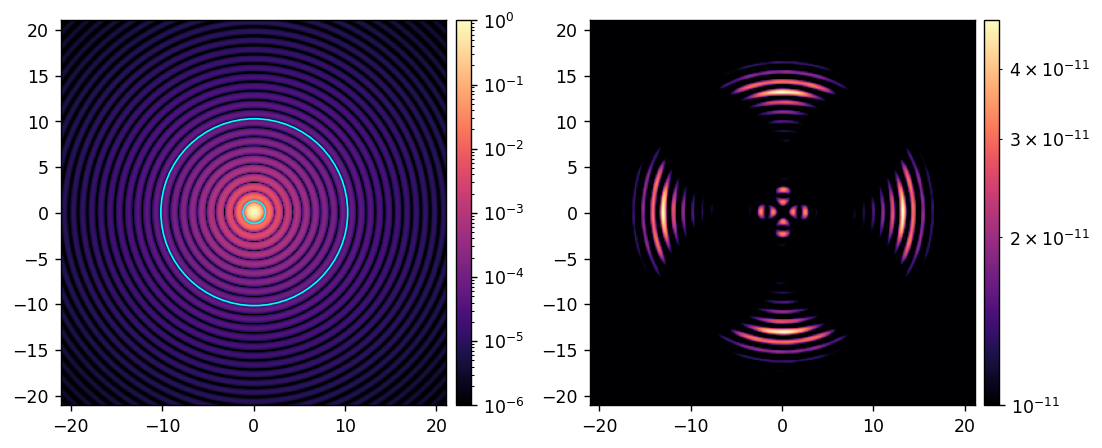

In [24]:
import esc_fresnel.esc_fresnel_subap as esc

reload(esc)
reload(esc_optics)

# poppy_log.disabled = False
poppy_log.disabled = True

M = esc.single()
# M.wfes = wfes

ref_psf = M.snap()

M.Imax_ref = xp.max(ref_psf)
M.use_vortex = True
ref_coro_im = M.snap()

psf_center = (M.camsci_pxscl_lamDc/2, M.camsci_pxscl_lamDc/2)
imshow(
    [ref_psf/M.Imax_ref, ref_coro_im], 
    cmaps=['magma']*2,
    norms=[LogNorm(1e-6), LogNorm(1e-11)],
    pxscls=[M.camsci_pxscl_lamDc]*2,
    all_patches=[ [Circle(psf_center, 1.22, fill=False, color='cyan'), Circle(psf_center, 10.22, fill=False, color='cyan')] ],
)

# Test M4 and FSM operation.

1


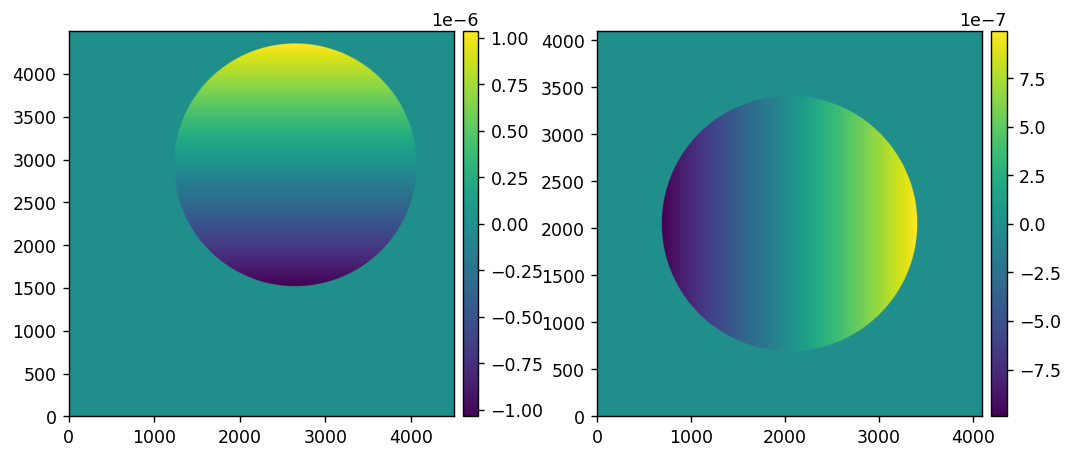

In [27]:
M.set_m4(np.array([0,1]))
M.set_fsm(np.array([1,0]))
imshow(
    [M.M4.opd, M.FSM.opd],
)

1


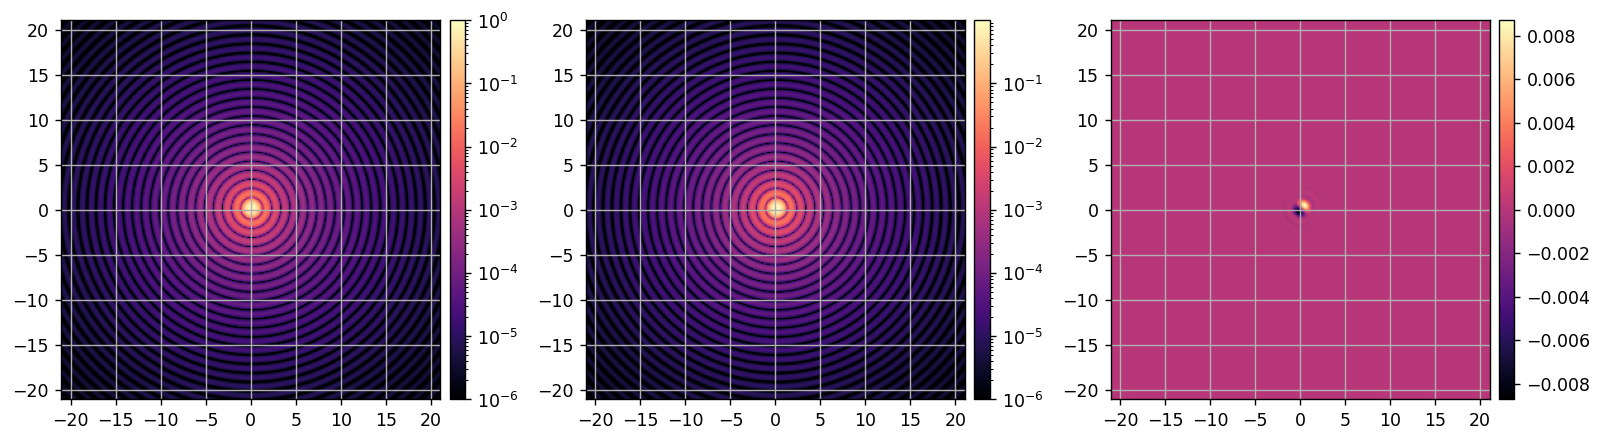

In [23]:
offset = np.array([ 20, 20 ])

m4_fsm_ratio = 1

M.npsf = 300
M.use_vortex = False
M.source_offset = (0, 0)
M.set_m4( [0,0] )
M.set_fsm( [0,0] )
psf1 = M.snap()

M.source_offset = offset
M.set_m4( -offset * m4_fsm_ratio )
M.set_fsm( -offset * (1 - m4_fsm_ratio) )
psf2 = M.snap()

ticks = np.arange(-20, 20.01, 5)

diff = psf1 - psf2

imshow(
    [psf1, psf2, diff],
    norms=[LogNorm(1e-6), LogNorm(1e-6)],
    grids=[1]*3,
    pxscls=[M.camsci_pxscl_lamDc]*3,
    xticks=[ticks]*3,
    yticks=[ticks]*3,
    cmaps=['magma']*3,
    wspace=0.3,
)


# Use ESC fresnel model to compute the wavefront at each plane and visualize the various pupil and focal planes.

Note that this is very memory intesive and is only meant to be used for understanding and debugging the Fresnel model. Standard propagations should only use calc_wf() or snap() methods, not calc_wfs(). 

In [23]:
M.Nm4

2835

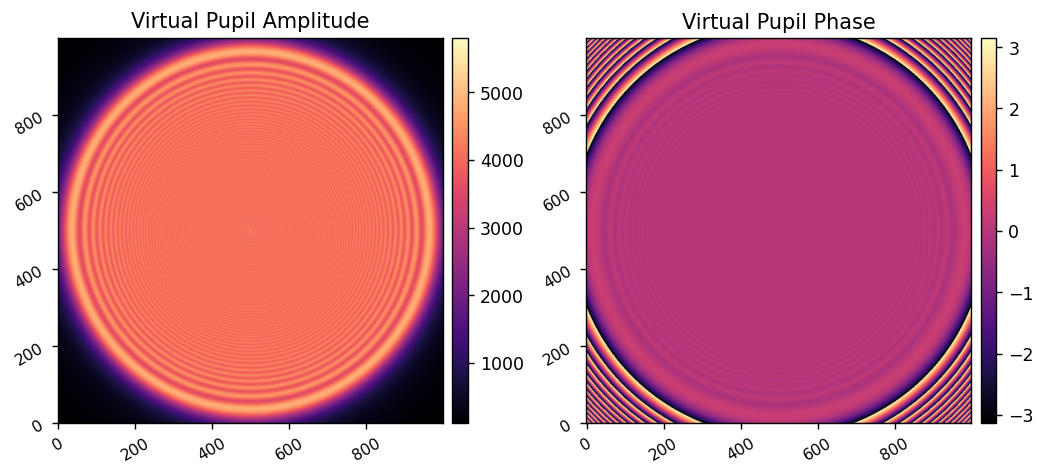

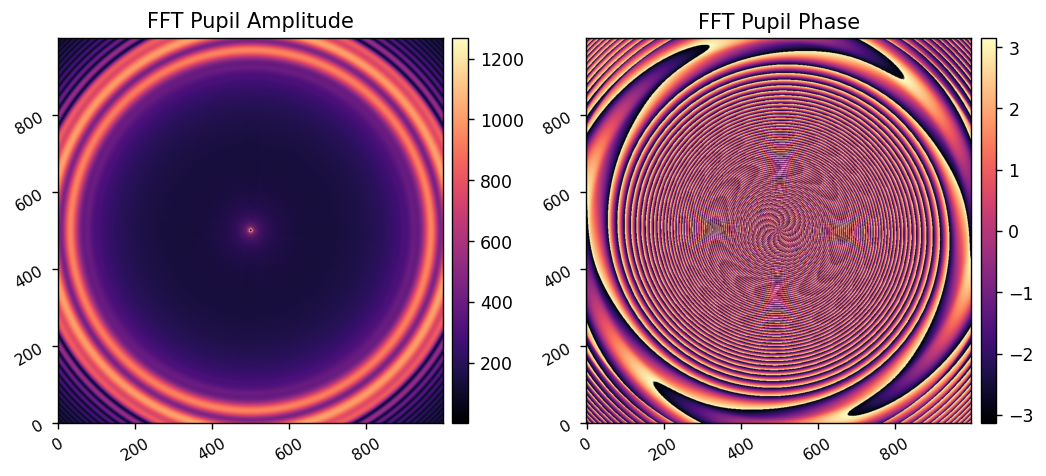

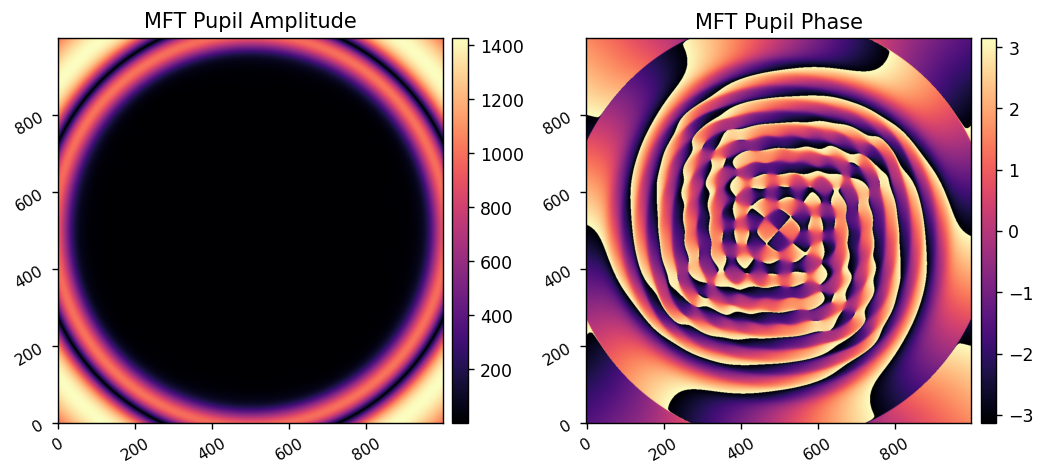

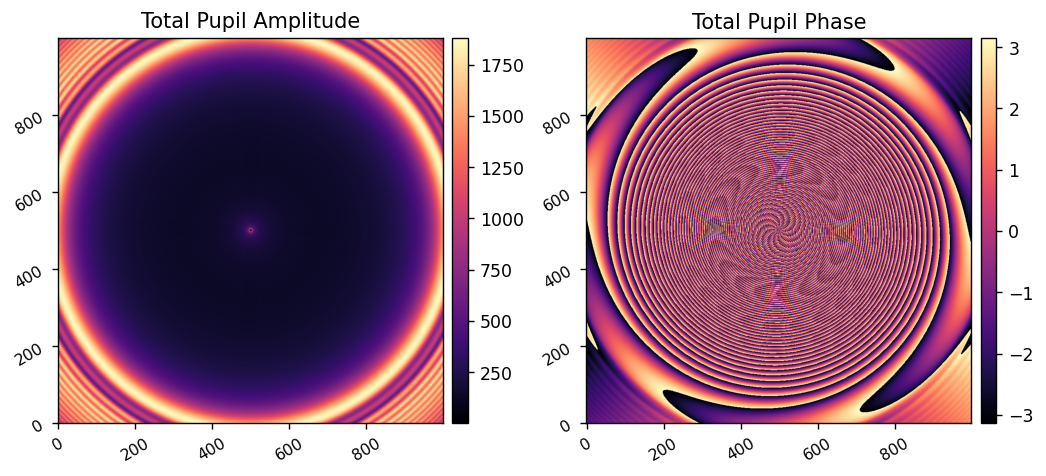

1


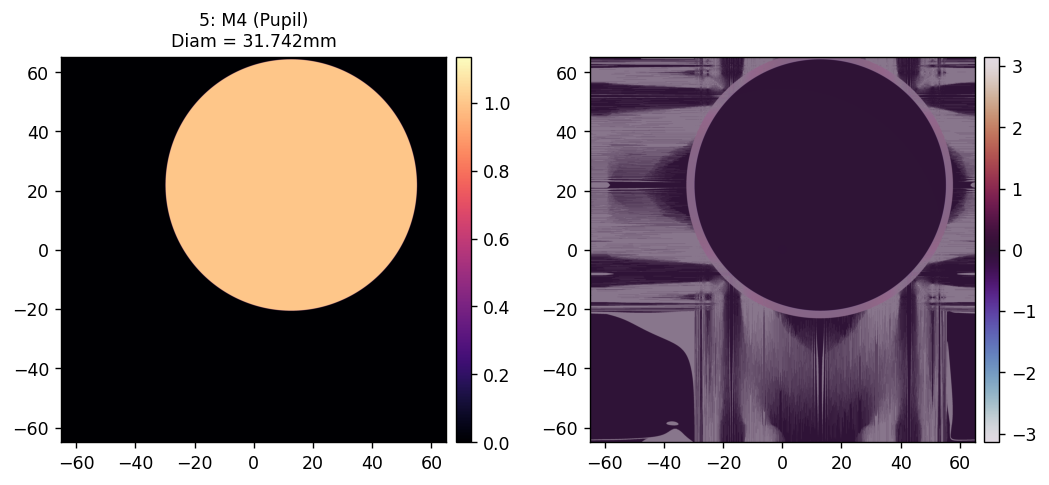

In [28]:
reload(esc)
reload(esc_optics)

poppy_log.disabled = True

M = esc.single(
    # npix=1000, 
    # oversample=6, 
    # oversample=8.192,
)
M.use_vortex = True
M.plot_vortex = True # this will display the intermediate steps while propagating through the vortex

# M.m4_corr = 5.5*u.mm
# M.pupil_mask_corr = 8.25*u.mm
# M.fsm_corr = -29.4*u.mm
# M.dm_corr = -6 *u.mm

# M.fsm_corr = -33.9*u.mm
# M.dm_corr = -10.5 *u.mm
# M.lyot_corr = -1.335*u.mm

wfs = M.calc_wfs()

i = 0
i = 5 # M4
# i = 9 # Pupil Mask
# i = 13 # FSM
# i = 18 # DM
# i = 25 # Lyot Plane
# i = 26 # Lyot Stop
wf = wfs[i]
imshow(
    [wf.amplitude, wf.phase], 
    titles=[f'{i:d}: '+wf.location[6:] + f'\nDiam = {2*wf.spot_radius().to_value(u.mm):.3f}mm'], 
    pxscls=[wf.pixelscale.to_value(u.mm/u.pix)]*2,
    # npix=[1.5*M.npix]*2, 
    cmaps=['magma', 'twilight'],
    # norms=[None, Normalize(-0.1, 0.1)],
)

In [11]:
31.742 * 6.5/2.43

84.90658436213991

In [7]:
6.5/2.43

2.674897119341564

In [ ]:
# mag = 
12.726

82719.00000000001

1


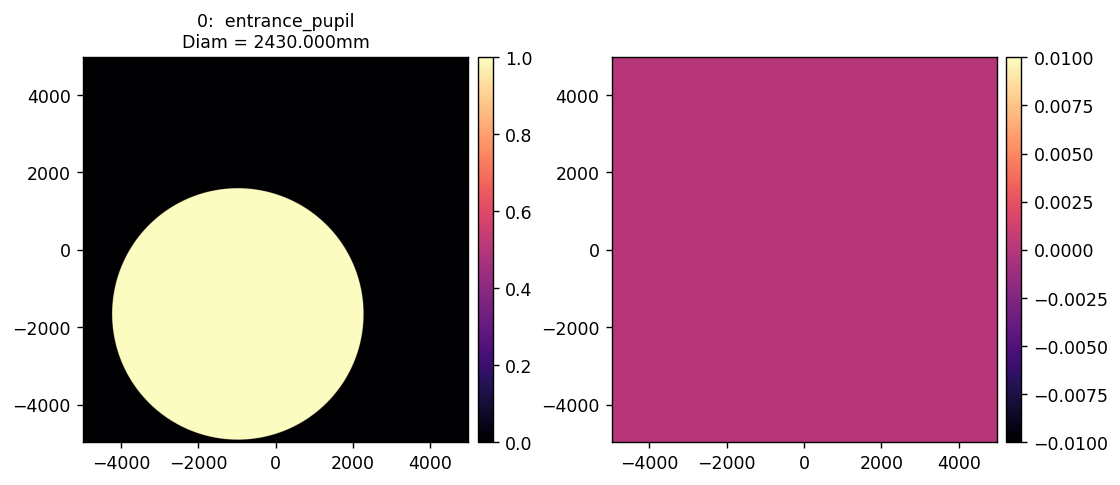

1


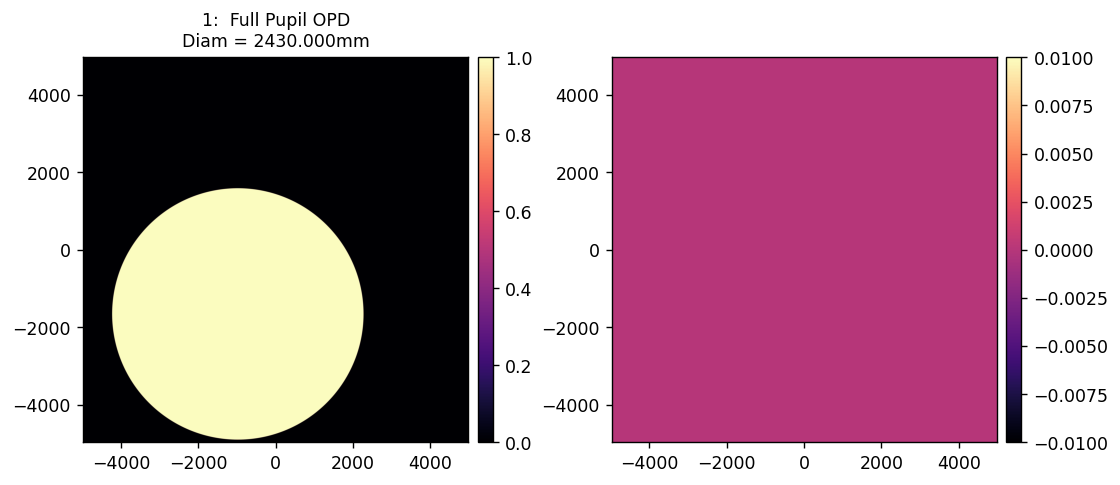

1


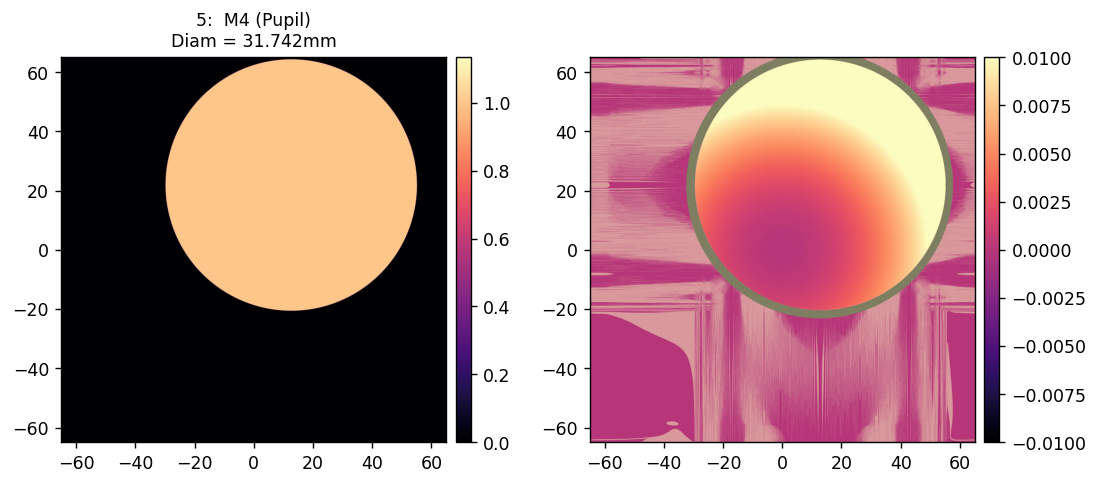

Focal Plane Correction:  0.0 mm
1


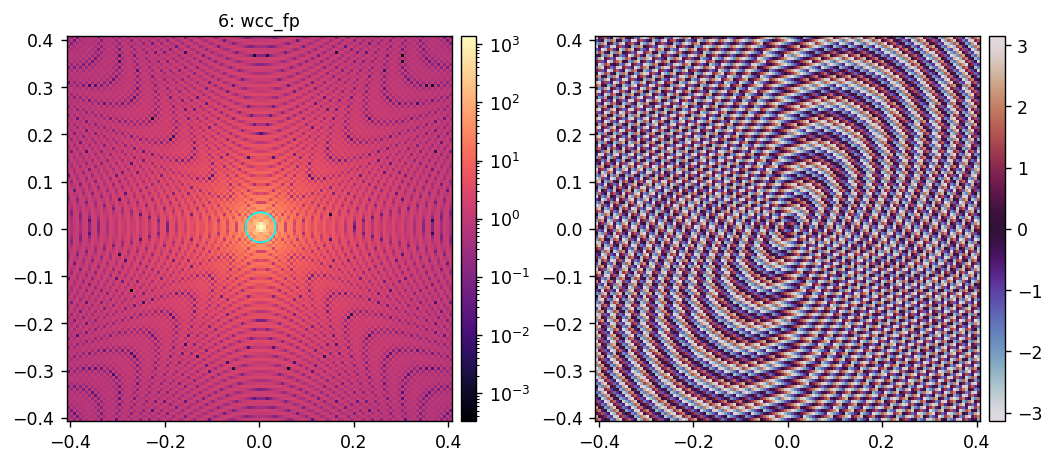

1


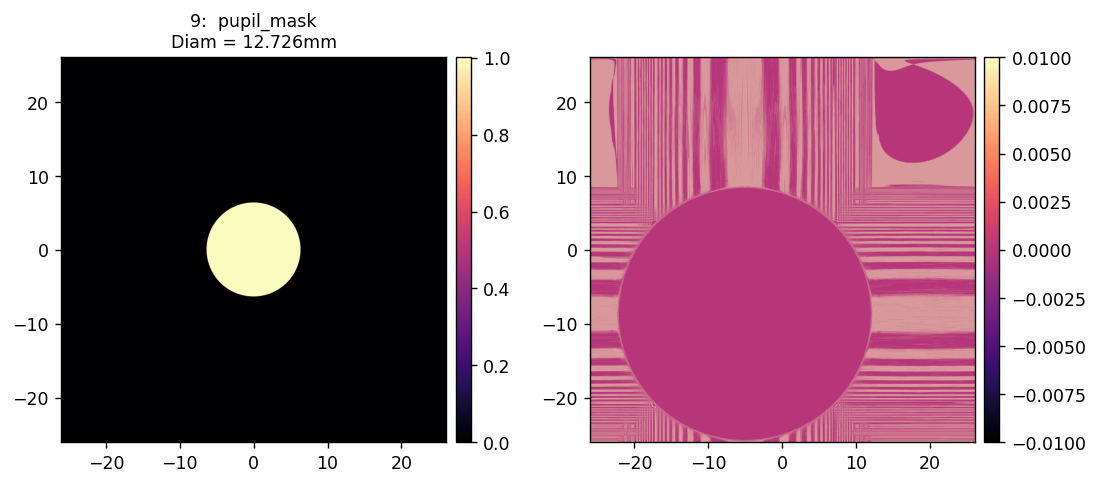

Focal Plane Correction:  0.0 mm
1


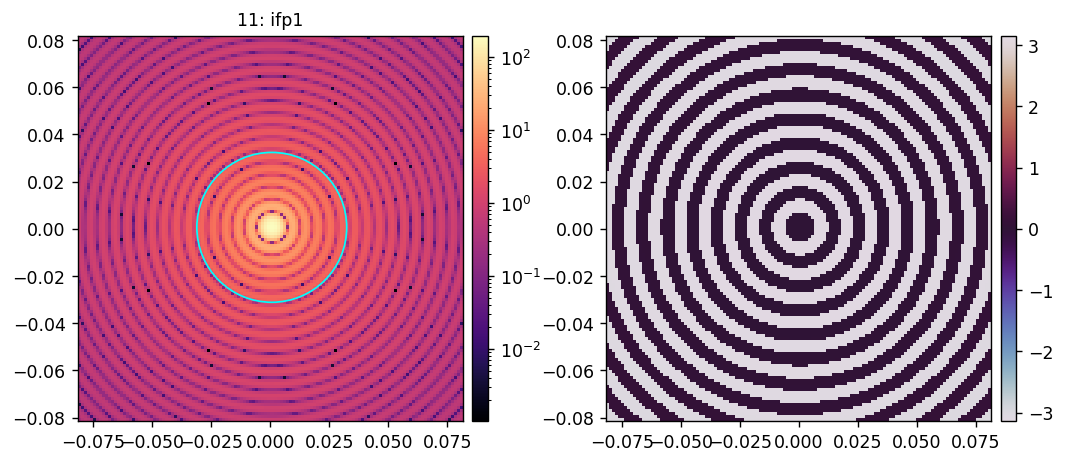

1


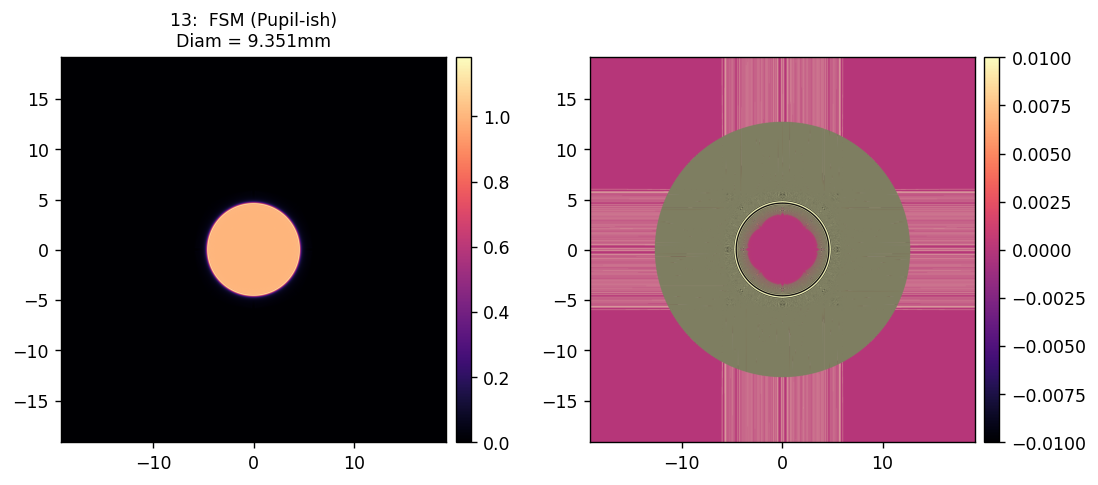

Focal Plane Correction:  0.0 mm
1


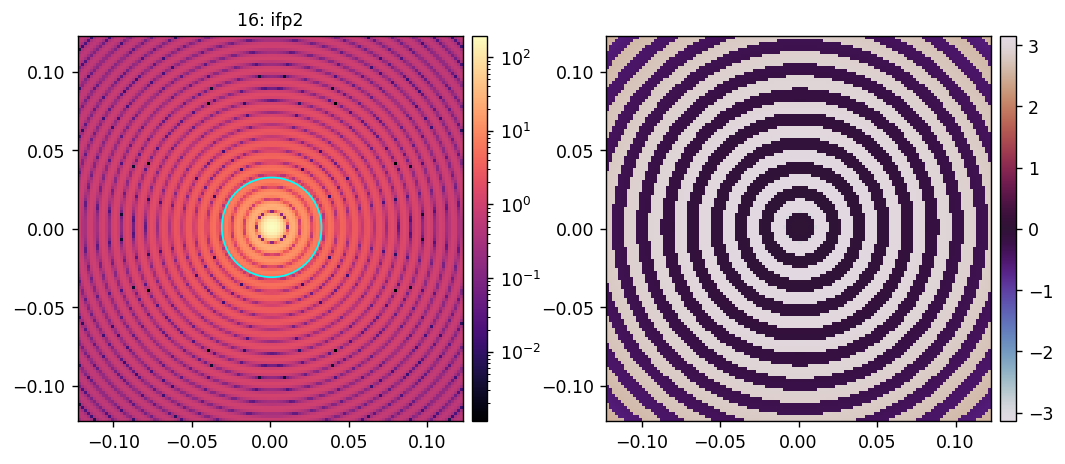

1


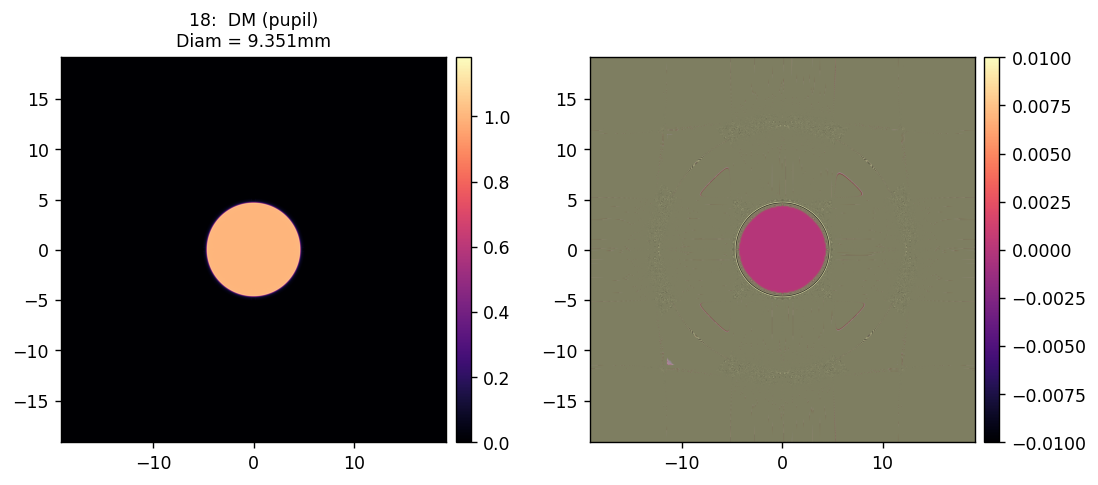

Focal Plane Correction:  -1541.0562467009754 mm
1


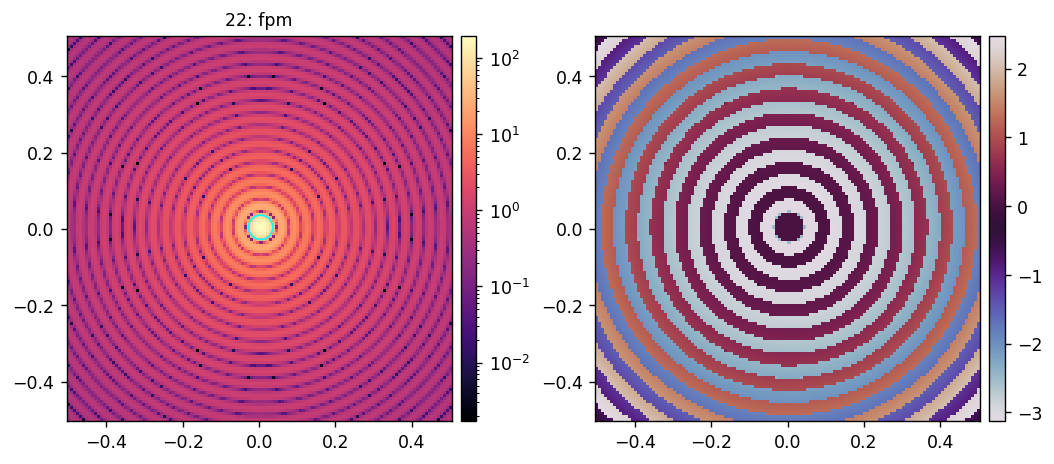

Focal Plane Correction:  0.0 mm
1


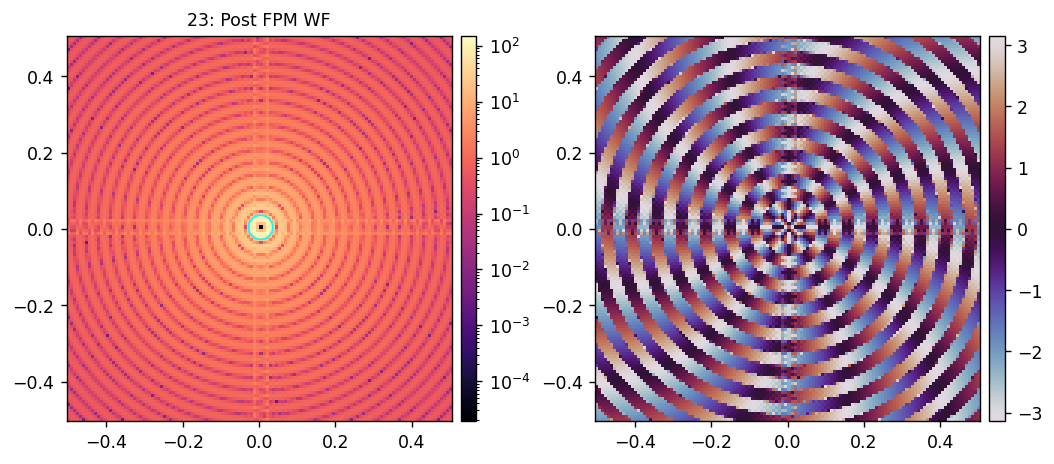

1


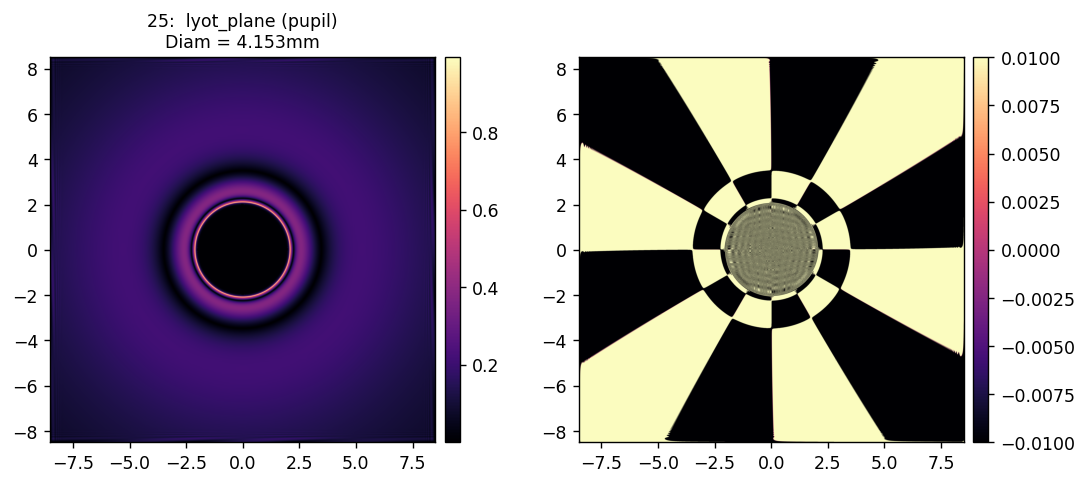

1


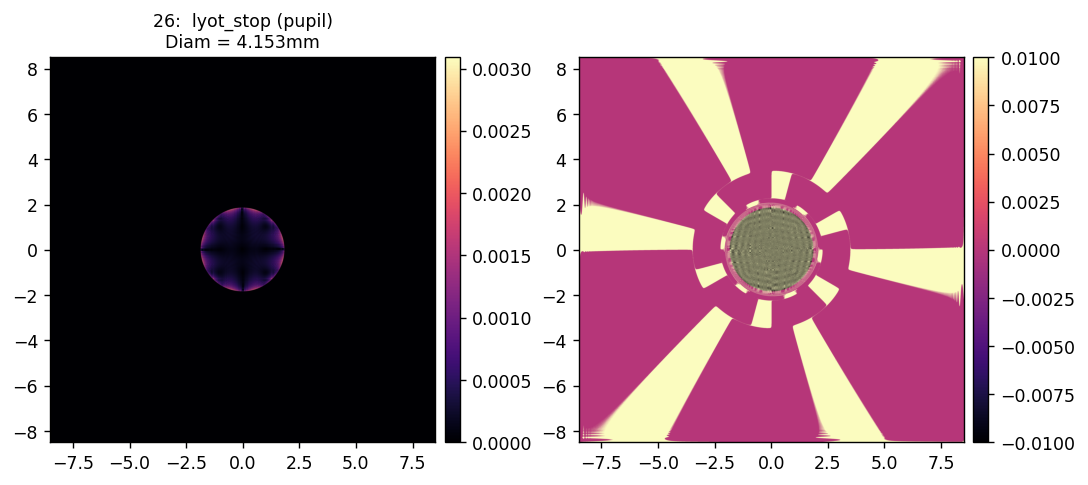

Focal Plane Correction:  0.0 mm
1


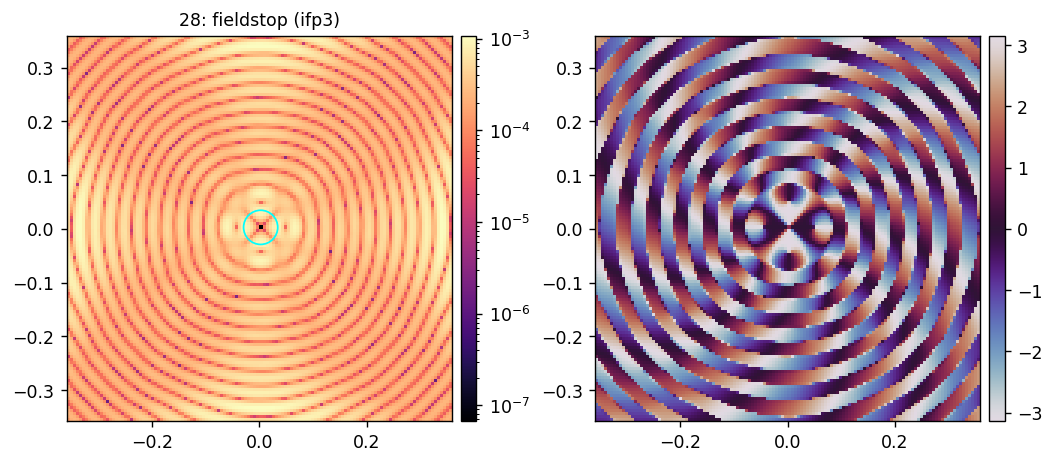

Focal Plane Correction:  0.0 mm
1


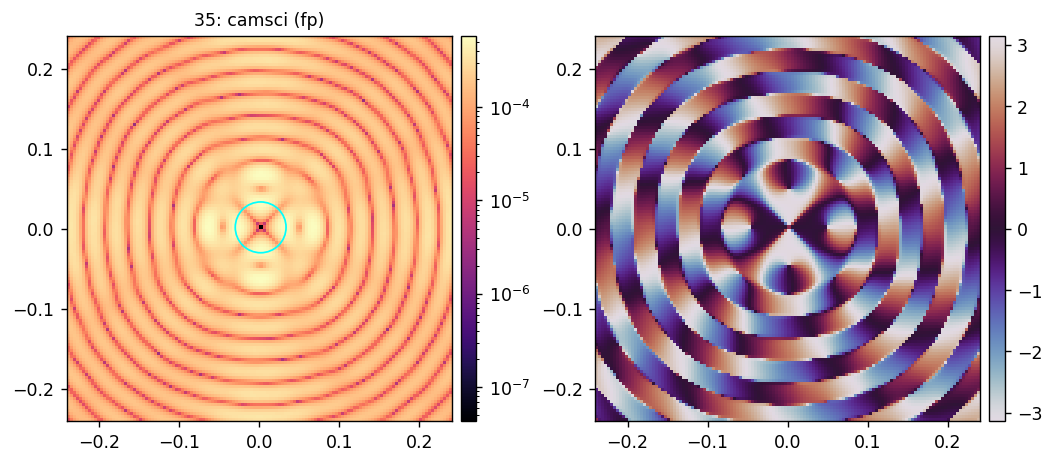

In [29]:
for i,wf in enumerate(wfs):
    if 'fp' in wf.location.lower():
        f_corr = wf.z_w0 - wf.z
        print('Focal Plane Correction: ', f_corr.to(u.mm))
        pxscl_mm = wf.pixelscale.to_value(u.mm/u.pix)
        airy_rad = 31.752*u.um
        imshow(
            [wf.amplitude, wf.phase,],
            titles=[f'{i:d}: '+wf.location[6:]], 
            cmaps=['magma', 'twilight'],
            pxscls=[pxscl_mm]*2, 
            npix=[128]*2, 
            norms=[LogNorm(), None],
            all_patches=[[Circle((pxscl_mm/2, pxscl_mm/2), airy_rad.to_value(u.mm), color='cyan', fill=False)]]
        )
    elif 'pupil' in wf.location.lower():
        imshow(
            [wf.amplitude, wf.phase], 
            titles=[f'{i:d}: '+wf.location[5:] + f'\nDiam = {2*wf.spot_radius().to_value(u.mm):.3f}mm'], 
            pxscls=[wf.pixelscale.to_value(u.mm/u.pix)]*2, 
            # npix=[2.5*M.npix], 
            cmaps=['magma', 'magma'],
            norms=[None, Normalize(vmin=-0.01, vmax=0.01)],
        )

# Use the esc_fresnel.multi() class in order to do parallelized propagations to simulate a broadband image. This requires the Ray package to perform the parallelization. 

In [2]:
reload(esc)

import ray
ray_esc = ray.remote(esc.single)

N_waves = 5
bw = 0.05
wavelength_c = 650*u.nm
waves = np.linspace(wavelength_c*(1 - bw/2), wavelength_c*(1 + bw/2), N_waves)
print(waves)

[633.75  641.875 650.    658.125 666.25 ] nm


In [3]:
ACTORS = []
for i in range(N_waves):
    params = {
        'wavelength':waves[i],
        # 'npix':1000,
        # 'oversample':4.096,
    }
    ACTORS.append(ray_esc.options(num_cpus=4, num_gpus=1).remote(**params))


2025-03-19 09:35:32,290	INFO worker.py:1832 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


(pid=1364552) /home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
(pid=1364552)   cupy._util.experimental('cupyx.jit.rawkernel')
(single pid=1364552) Oversampling > 2x suggested for reliable results in Fresnel propagation.
(pid=1364548) /home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future. [repeated 4x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(pid=1364548)   cupy._util.experimental('cupyx.jit.rawkernel') [repeated 4x across cluster]
(single pid=1364542) Oversampling > 2x suggested for reliable results in Fresnel propagation.


1


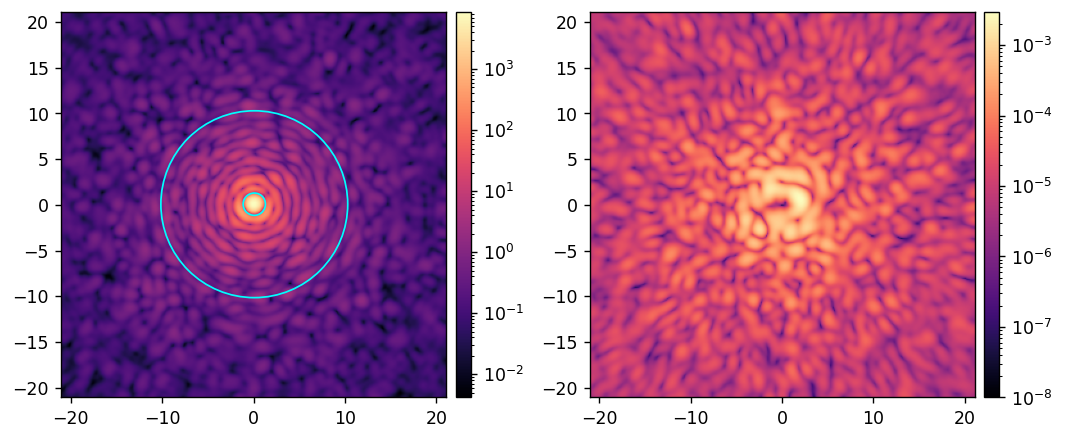

In [12]:
reload(esc)
M = esc.parallel(ACTORS)
M.setattr('wfes', wfes)

M.setattr('Imax_ref', 1)
M.setattr('use_vortex', False)
ref_psf = M.snap()
# M.Imax_ref = xp.max(ref_psf)
M.setattr('Imax_ref', xp.max(ref_psf))

M.setattr('use_vortex', True)
ref_coro_im = M.snap()

psf_center = (M.camsci_pxscl_lamDc/2, M.camsci_pxscl_lamDc/2)
imshow(
    [ref_psf/M.Imax_ref, ref_coro_im], 
    cmaps=['magma']*2,
    norms=[LogNorm(), LogNorm(1e-8)],
    pxscls=[M.camsci_pxscl_lamDc]*2,
    all_patches=[ [Circle(psf_center, 1.22, fill=False, color='cyan'), Circle(psf_center, 10.22, fill=False, color='cyan')] ],
)

In [9]:
M.npix, M.oversample

(1000, 4.096)

In [11]:
M.setattr('use_vortex', True)

%timeit -n 10 M.snap()

394 ms ± 3.74 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


1


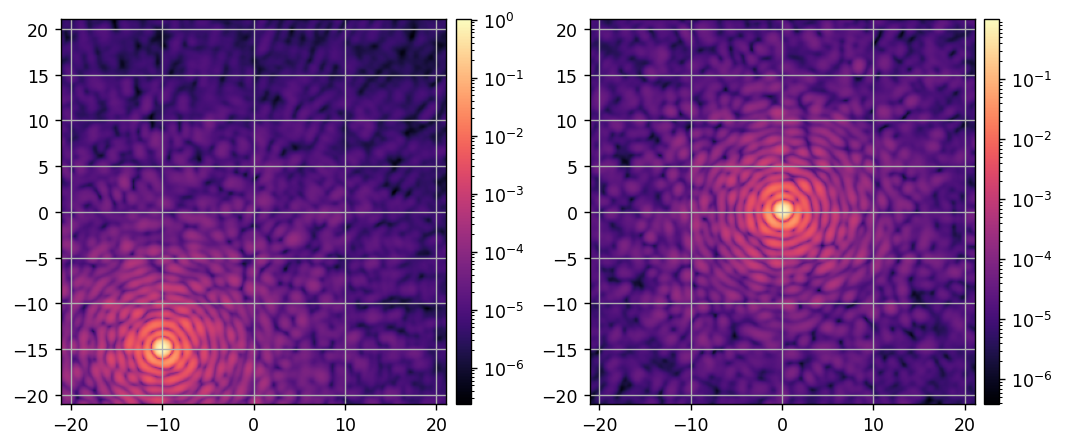

In [19]:
source_offset = np.array([-10, -15])
M.setattr('use_vortex', False)

M.setattr('source_offset', source_offset)
M.set_m4( [0, 0] )
M.set_fsm( [0, 0] )
psf1 = M.snap()

M.setattr('source_offset', source_offset)
M.set_m4( -source_offset )
# M.set_fsm( -source_offset )
psf2 = M.snap()

imshow(
    [psf1, psf2], 
    cmaps=['magma']*2,
    norms=[LogNorm(), LogNorm()],
    pxscls=[M.camsci_pxscl_lamDc]*2,
    grids=[1, 1],
)